In [ ]:
""" Clustering Tutorial - Fully Functional Python Script Dataset: gaming_addiction.csv Topics Covered -------------- 1. Load the dataset 2. Understand Clustering 3. Data Preprocessing 4. Select clustering features 5. Handle categorical variables 6. Scale the data 7. Find the optimal number of clusters (Elbow Method) 8. Train K-Means 9. Evaluate using Silhouette Score 10. Visualize clusters using PCA 11. Interpret clusters Install: pip install pandas numpy matplotlib scikit-learn """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [ ]:
# ==========================================================
# STEP 1 : LOAD DATASET
# ==========================================================

print("="*60)
print("STEP 1 : Loading Dataset")
print("="*60)

df = pd.read_csv("Wholesale customers data.csv")

print(df.head())
print("\nShape:", df.shape)

STEP 1 : Loading Dataset
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Shape: (440, 8)


In [ ]:
# ==========================================================
# STEP 2 : REMOVE IDENTIFIER COLUMN
# ==========================================================

if "user_id" in df.columns:
    df = df.drop(columns=["user_id"])



In [ ]:
# ==========================================================
# STEP 3 : CONVERT CATEGORICAL DATA
# ==========================================================

print("\nConverting categorical columns...")

categorical_cols = df.select_dtypes(include=["object"]).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Dataset Shape After Encoding:", df.shape)


Converting categorical columns...
Dataset Shape After Encoding: (440, 8)


In [ ]:
# ==========================================================
# STEP 4 : SELECT FEATURES
# ==========================================================

print("\nPreparing features...")

X = df.copy()


Preparing features...


In [ ]:
# ==========================================================
# STEP 5 : FEATURE SCALING
# ==========================================================

print("Scaling data...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scaling data...



Finding optimal K...


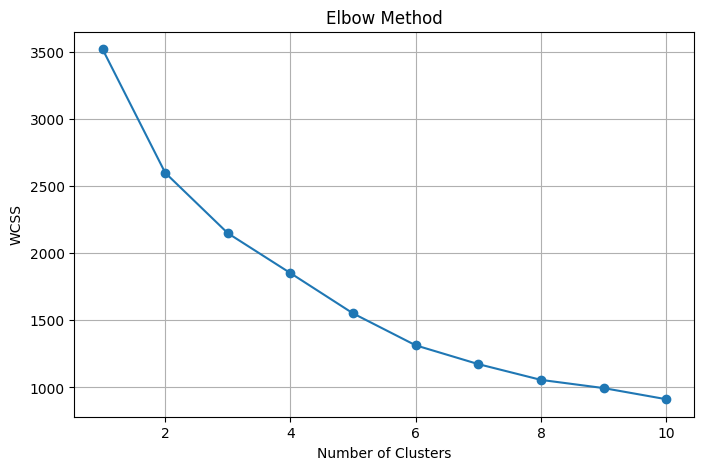

 Choose the point where the graph bends. That value is usually the optimal number of clusters. For this example we use K = 3. 


In [ ]:
# ==========================================================
# STEP 6 : ELBOW METHOD
# ==========================================================

print("\nFinding optimal K...")

wcss = []

for k in range(1,11):
    model = KMeans(n_clusters=k,
                   random_state=42,
                   n_init=10)

    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

print(""" Choose the point where the graph bends. That value is usually the optimal number of clusters. For this example we use K = 3. """)

In [ ]:
# ==========================================================
# STEP 7 : TRAIN KMEANS
# ==========================================================

k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("\nCluster Counts")
print(df["Cluster"].value_counts())



Cluster Counts
Cluster
1    297
0    130
2     13
Name: count, dtype: int64


In [ ]:
# ==========================================================
# STEP 8 : EVALUATION
# ==========================================================

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score =", round(score,3))

if score > 0.7:
    print("Excellent clustering")
elif score > 0.5:
    print("Good clustering")
elif score > 0.3:
    print("Average clustering")
else:
    print("Poor clustering")


Silhouette Score = 0.357
Average clustering



Reducing dimensions using PCA...


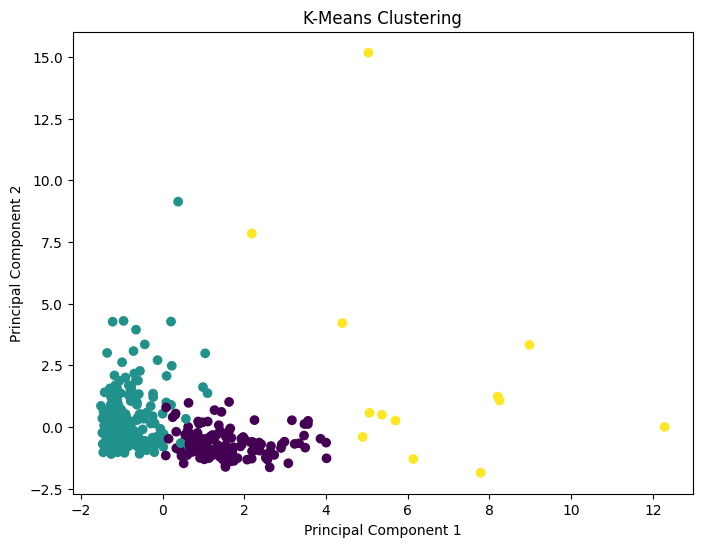

In [ ]:
# ==========================================================
# STEP 9 : PCA VISUALIZATION
# ==========================================================

print("\nReducing dimensions using PCA...")

pca = PCA(n_components=2)

reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [ ]:
print("\nAnalyzing cluster characteristics...")

cluster_analysis = df.groupby('Cluster').mean()
display(cluster_analysis)

print("\nInterpretation guidance: Look at the mean values for each feature across the clusters. High values indicate a strong presence of that feature in the cluster, while low values indicate a weak presence. This helps to characterize each customer segment.")


Analyzing cluster characteristics...


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,2.000000,2.623077,8165.915385,8748.515385,13905.492308,1441.630769,5991.146154,1535.007692
1,1.003367,2.505051,13075.898990,3218.737374,3855.696970,3620.400673,776.875421,1242.249158
2,1.846154,2.615385,25770.769231,35160.384615,41977.384615,6844.538462,19867.384615,7880.307692



Interpretation guidance: Look at the mean values for each feature across the clusters. High values indicate a strong presence of that feature in the cluster, while low values indicate a weak presence. This helps to characterize each customer segment.
